# "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ## Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

> ## Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

In [57]:
import os
import sys
import time
import subprocess
from datetime import datetime
from pathlib import Path
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import FunctionTransformer
import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
import time

from sqlalchemy import create_engine
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, KBinsDiscretizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from catboost import CatBoostRegressor
from autofeat import AutoFeatRegressor

In [3]:


EXPERIMENT_NAME = "model_FE_matevosov"
TABLE_NAME = "public.real_estate_dataset_clean"
TARGET_COL = "price"

REGISTERED_MODEL_NAME = "real_estate_price_model_matevosov"

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2  

NOTEBOOK_PATH = Path("model_improvement") / "model_improvement.ipynb"
ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)

def require_env(name: str) -> str:
    val = os.getenv(name)
    if not val:
        raise RuntimeError(f"Environment variable {name} is required")
    return val

def get_db_uri() -> str:
    host = require_env("DB_DESTINATION_HOST")
    port = require_env("DB_DESTINATION_PORT")
    user = require_env("DB_DESTINATION_USER")
    password = require_env("DB_DESTINATION_PASSWORD")
    dbname = os.getenv("DB_DESTINATION_DBNAME") or require_env("DB_DESTINATION_NAME")
    return f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{dbname}"

def load_dataset() -> pd.DataFrame:
    engine = create_engine(get_db_uri())
    df = pd.read_sql(f"SELECT * FROM {TABLE_NAME}", engine)
    if TARGET_COL not in df.columns:
        raise RuntimeError(f"Target column {TARGET_COL} not found in {TABLE_NAME}")
    return df

def setup_mlflow():
    tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(EXPERIMENT_NAME)

def log_environment():
    try:
        freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    except Exception as e:
        freeze = f"pip freeze failed: {e}"
    mlflow.log_text(freeze, "environment/pip_freeze.txt")

setup_mlflow()

df = load_dataset()

y = df[TARGET_COL].to_numpy()
X = df.drop(columns=[TARGET_COL])
X = X[[c for c in X.columns if not X[c].isna().all()]]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)




## Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


### Общий обзор датасета

In [2]:
df.head(3)

,flat_id,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator
0,0,6220,9,9.9,19.900000,1,False,False,35.099998,9500000,1965,6,55.717113,37.781120,2.64,84,12,True
1,2,17821,9,9.0,32.000000,2,False,False,56.000000,13500000,2000,4,55.740040,37.761742,2.70,80,10,True
2,3,18579,1,10.1,43.099998,3,False,False,76.000000,20000000,2002,4,55.672016,37.570877,2.64,771,17,True


### Типы данных

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119522 entries, 0 to 119521
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   flat_id            119522 non-null  int64  
 1   building_id        119522 non-null  int64  
 2   floor              119522 non-null  int64  
 3   kitchen_area       119522 non-null  float64
 4   living_area        119522 non-null  float64
 5   rooms              119522 non-null  int64  
 6   is_apartment       119522 non-null  bool   
 7   studio             119522 non-null  bool   
 8   total_area         119522 non-null  float64
 9   price              119522 non-null  int64  
 10  build_year         119522 non-null  int64  
 11  building_type_int  119522 non-null  int64  
 12  latitude           119522 non-null  float64
 13  longitude          119522 non-null  float64
 14  ceiling_height     119522 non-null  float64
 15  flats_count        119522 non-null  int64  
 16  fl

### Статистики признаков

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flat_id,119522.0,NaN,NaN,NaN,72221.814059,41127.096888,0.0,35647.25,73998.5,107350.75,141361.0
building_id,119522.0,NaN,NaN,NaN,13741.100768,6858.762476,1.0,8400.25,13890.0,19858.0,24620.0
floor,119522.0,NaN,NaN,NaN,7.328709,5.45439,1.0,3.0,6.0,10.0,56.0
kitchen_area,119522.0,NaN,NaN,NaN,9.29683,2.895663,1.75,7.0,9.0,10.5,15.75
living_area,119522.0,NaN,NaN,NaN,34.121134,15.379146,2.0,20.4,30.9,43.5,78.150001
rooms,119522.0,NaN,NaN,NaN,2.090393,0.950782,1.0,1.0,2.0,3.0,17.0
is_apartment,119522,2,False,118584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
studio,119522,1,False,119522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_area,119522.0,NaN,NaN,NaN,57.02666,21.870562,11.5,39.0,52.0,68.900002,113.750004
price,119522.0,NaN,NaN,NaN,13435399.163049,6196669.146686,11.0,8890000.0,11600000.0,16200000.0,27165000.0


Датасет содержит 119522 строк и 18 признаков, пропусков нет, типы данных представлены int64, float64 и bool.

### Сводка по категориальным и булевым

In [5]:

df.describe(include=["object", "category", "bool"]).T.head(30)


,count,unique,top,freq
is_apartment,119522,2,False,118584
studio,119522,1,False,119522
has_elevator,119522,2,True,107224


### Анализ признаков для модели

In [6]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()

forced_cat = ["building_type_int"]
for c in forced_cat:
    if c in num_cols:
        num_cols.remove(c)
    if c not in cat_cols:
        cat_cols.append(c)

# Эвристика по id-полям
id_like_cols = [c for c in X.columns if c.lower() == "id" or c.lower().endswith("_id")]

len(num_cols), len(cat_cols), len(bool_cols), id_like_cols[:10]



(13, 1, 3, ['flat_id', 'building_id'])

В этой ячейке выделяются списки числовых, категориальных и булевых признаков, а также автоматически находится набор id-похожих колонок для последующего исключения из моделирования. Так же нужно чтобы building_type_int попадала в категориальные переменные.

In [60]:
X['studio'].value_counts()

studio
False    119522
Name: count, dtype: int64

Все значения studio равны 0. Переменная константна. Можно избавиться потом.

Проверка пропусков

In [7]:

miss_cnt = X.isna().sum()
miss_pct = (miss_cnt / len(X) * 100).round(4)

missing_df = (
    pd.DataFrame({"missing_cnt": miss_cnt, "missing_pct": miss_pct})
    .sort_values("missing_pct", ascending=False)
)

missing_df.head()


,missing_cnt,missing_pct
flat_id,0,0.0
building_id,0,0.0
floor,0,0.0
kitchen_area,0,0.0
living_area,0,0.0


Проверка дубликатов строк целиком

In [8]:

dup_rows = df.duplicated().sum()
dup_rows


0

Сохраним отчет о пропусках

In [9]:

eda_dir = ART_DIR / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

miss_cnt = X.isna().sum()
miss_total = int(miss_cnt.sum())

miss_pct = (miss_cnt / len(X) * 100).round(4)

missing_df = (
    pd.DataFrame({"missing_cnt": miss_cnt, "missing_pct": miss_pct})
    .sort_values(["missing_cnt", "missing_pct"], ascending=False)
)

if miss_total == 0:
    print("Пропусков в признаках нет: missing_cnt=0 для всех колонок.")
    # Для проверяемости все равно покажем небольшой фрагмент таблицы
    missing_df.head(10)
    p_missing = None
else:
    # Показываем только колонки, где пропуски реально есть
    missing_nonzero = missing_df[missing_df["missing_cnt"] > 0].copy()

    n_show = min(30, len(missing_nonzero))
    display_df = missing_nonzero.head(n_show)

    print(f"Найдены пропуски: всего {miss_total} значений. Показаны топ-{n_show} колонок по числу пропусков.")
    display_df

    plt.figure(figsize=(10, 6))
    sns.barplot(x=display_df["missing_pct"].values, y=display_df.index)
    plt.title(f"Доля пропусков по признакам, топ-{n_show}")
    plt.xlabel("Пропуски, %")
    p_missing = eda_dir / "missingness_top.png"
    plt.savefig(p_missing, dpi=150, bbox_inches="tight")
    # plt.close()

p_missing


Пропусков в признаках нет: missing_cnt=0 для всех колонок.


### Анализ целевой переменной

(PosixPath('artifacts/eda/target_hist_kde.png'),
 PosixPath('artifacts/eda/target_boxplot.png'),
 PosixPath('artifacts/eda/target_qqplot.png'))

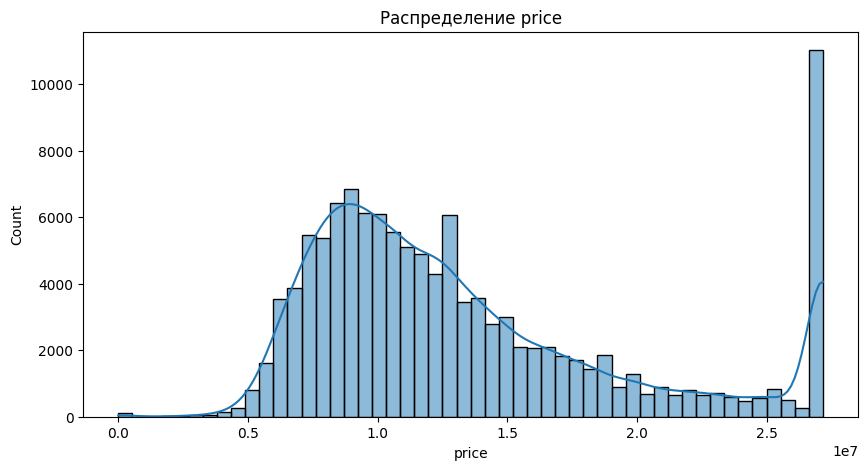

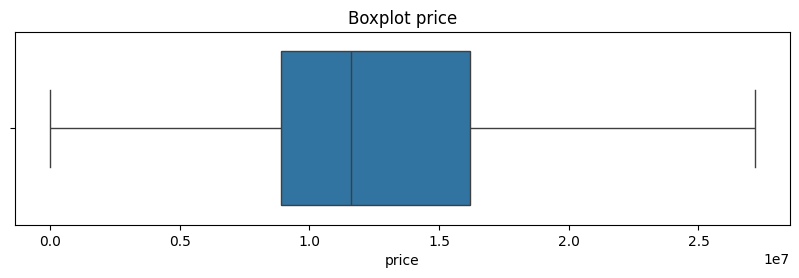

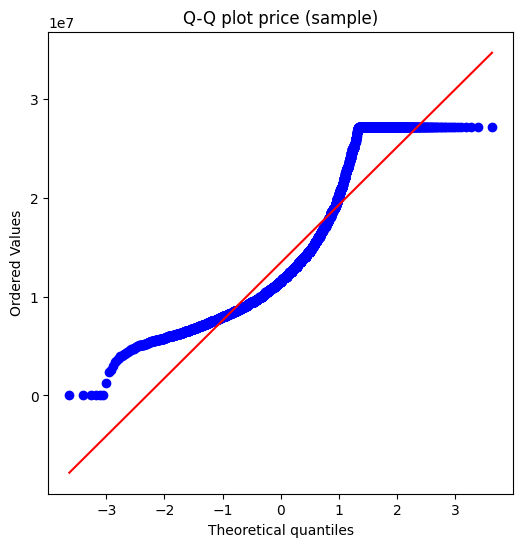

In [10]:
target = df[TARGET_COL].dropna()

# Распределение
plt.figure(figsize=(10, 5))
sns.histplot(target, bins=50, kde=True)
plt.title(f"Распределение {TARGET_COL}")
p_target_hist = eda_dir / "target_hist_kde.png"
plt.savefig(p_target_hist, dpi=150, bbox_inches="tight")
# plt.close()

# Boxplot
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=target)
plt.title(f"Boxplot {TARGET_COL}")
p_target_box = eda_dir / "target_boxplot.png"
plt.savefig(p_target_box, dpi=150, bbox_inches="tight")
# plt.close()

# Q-Q plot (на подвыборке, чтобы не перегружать)
qq_sample = target.sample(n=min(len(target), 5000), random_state=RANDOM_STATE)
plt.figure(figsize=(6, 6))
stats.probplot(qq_sample, dist="norm", plot=plt)
plt.title(f"Q-Q plot {TARGET_COL} (sample)")
p_target_qq = eda_dir / "target_qqplot.png"
plt.savefig(p_target_qq, dpi=150, bbox_inches="tight")
# plt.close()

p_target_hist, p_target_box, p_target_qq


Числовые характеристики таргета для вывода

In [11]:
q01, q50, q99 = np.quantile(target, [0.01, 0.5, 0.99])
skew = float(target.skew())

target_summary = {
    "q01": float(q01),
    "median": float(q50),
    "q99": float(q99),
    "skew": float(skew),
}
target_summary


{'q01': 5300000.0,
 'median': 11600000.0,
 'q99': 27165000.0,
 'skew': 1.0041829201715486}

### Анализ целевой переменной в зависимости от различных признаков

,pearson,spearman,abs_pearson
total_area,0.791287,0.748188,0.791287
living_area,0.739320,0.696032,0.739320
rooms,0.627752,0.637443,0.627752
kitchen_area,0.552719,0.471499,0.552719
ceiling_height,0.518251,0.453683,0.518251
floors_total,0.244026,0.192669,0.244026
floor,0.171996,0.137518,0.171996
building_id,0.144270,0.160057,0.144270
build_year,0.130731,0.162107,0.130731
longitude,-0.117981,-0.149365,0.117981


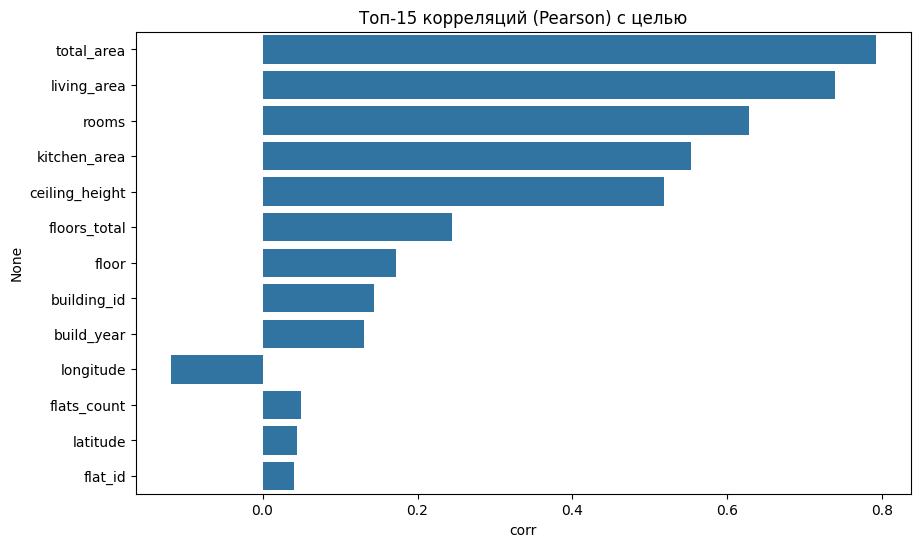

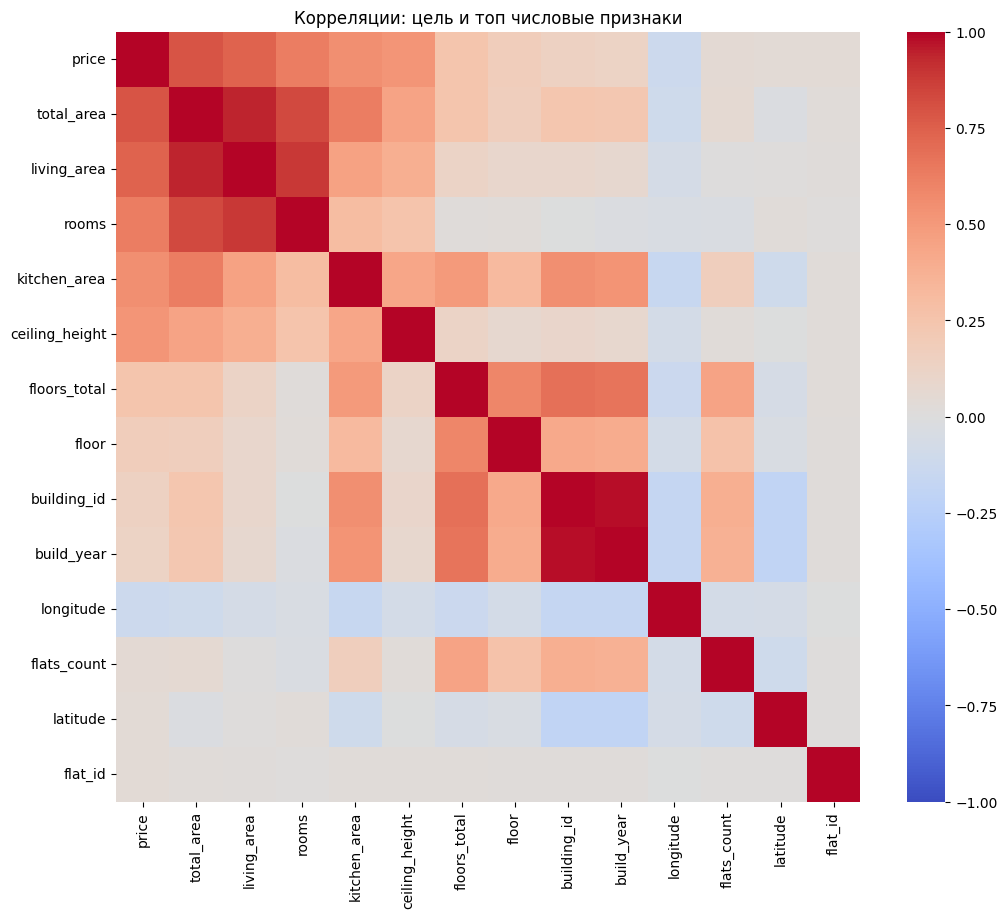

In [12]:
p_corr_heatmap = None
p_corr_bar = None

if len(num_cols) > 0:
    tmp = pd.DataFrame(X[num_cols]).copy()
    tmp[TARGET_COL] = df[TARGET_COL].to_numpy()

    corr_pearson = tmp.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
    corr_spearman = tmp.corr(method="spearman", numeric_only=True)[TARGET_COL].drop(TARGET_COL)

    corr_table = pd.DataFrame({
        "pearson": corr_pearson,
        "spearman": corr_spearman,
        "abs_pearson": corr_pearson.abs()
    }).sort_values("abs_pearson", ascending=False)

    top_feats = corr_table.head(20).index.tolist()

    # Barplot топ-15 корреляций
    top15 = corr_table.head(15)["pearson"].sort_values(key=lambda s: s.abs(), ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top15.values, y=top15.index)
    plt.title("Топ-15 корреляций (Pearson) с целью")
    plt.xlabel("corr")
    p_corr_bar = eda_dir / "corr_top15_bar.png"
    plt.savefig(p_corr_bar, dpi=150, bbox_inches="tight")
    # plt.close()

    # Heatmap для target + top признаков
    if len(top_feats) >= 2:
        corr_matrix = tmp[[TARGET_COL] + top_feats].corr(numeric_only=True)
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, center=0, cmap='coolwarm', vmin=-1, vmax=1.0)
        plt.title("Корреляции: цель и топ числовые признаки")
        p_corr_heatmap = eda_dir / "corr_heatmap_top.png"
        plt.savefig(p_corr_heatmap, dpi=150, bbox_inches="tight")
        # plt.close()

corr_table.head(10) if len(num_cols) > 0 else "Нет числовых признаков"


Корреляционный анализ показывает, что наибольшая связь с price у total_area, living_area, rooms, kitchen_area и ceiling_height (положительная), у building_type_int заметная отрицательная, а heatmap дополнительно подтверждает сильную взаимосвязь между площадями и рядом технических признаков, что важно учитывать из-за мультиколлинеарности.

### 2.5 Выводы после EDA

In [13]:
miss_total = int(missing_df["missing_cnt"].sum())
missing_nonzero = missing_df[missing_df["missing_cnt"] > 0].copy()
# Пропуски и дубликаты
if miss_total == 0:
    miss_part = "Пропусков в признаках нет"
else:
    top_miss5 = missing_nonzero.head(5)
    top_miss5_txt = ", ".join([f"{idx}={row.missing_pct:.4f}%" for idx, row in top_miss5.iterrows()])
    miss_part = f"Найдены пропуски, топ-5 по доле пропусков: {top_miss5_txt}"

if dup_rows == 0:
    dup_part = "Дубликатов строк целиком нет"
else:
    dup_part = f"Дубликаты строк целиком: {dup_rows}"

insight_1 = f"{miss_part}. {dup_part}."

# Таргет
insight_2 = (
    f"Целевая переменная {TARGET_COL}: q01={target_summary['q01']:.2f}, "
    f"median={target_summary['median']:.2f}, q99={target_summary['q99']:.2f}, "
    f"skew={target_summary['skew']:.3f}. "
    "Это влияет на устойчивость метрик и возможные трансформации таргета."
)

# Корреляции
if "corr_table" in globals() and len(num_cols) > 0 and len(corr_table) > 0:
    top_feat = corr_table.index[0]
    top_val = float(corr_table.loc[top_feat, "pearson"])
    insight_3 = f"Связь с целью: наиболее коррелирующий числовой признак: {top_feat} (Pearson={top_val:.3f})."
else:
    insight_3 = "Связь с целью: числовых признаков для корреляционного анализа недостаточно."

# Идентификаторы
insight_4 = ""
if len(id_like_cols) > 0:
    insight_4 = f"Признаки-идентификаторы, кандидат на исключение из моделирования: {', '.join(id_like_cols)}."

eda_findings_md = (
    "## Этап 2. EDA: ключевые выводы\n\n"
    f"1) {insight_1}\n"
    f"2) {insight_2}\n"
    f"3) {insight_3}\n"
)

if insight_4:
    eda_findings_md += f"4) {insight_4}\n"

print(eda_findings_md)


## Этап 2. EDA: ключевые выводы

1) Пропусков в признаках нет. Дубликатов строк целиком нет.
2) Целевая переменная price: q01=5300000.00, median=11600000.00, q99=27165000.00, skew=1.004. Это влияет на устойчивость метрик и возможные трансформации таргета.
3) Связь с целью: наиболее коррелирующий числовой признак: total_area (Pearson=0.791).
4) Признаки-идентификаторы, кандидат на исключение из моделирования: flat_id, building_id.



### 2.6 логирование артефактов в MLflow

In [14]:
run_name = "02_eda"

# Безопасно собираем графики, даже если некоторые переменные не были созданы
plot_files = []

maybe_plots = [
    "p_missing",
    "p_target_hist", "p_target_box", "p_target_qq",
    "p_corr_bar", "p_corr_heatmap",
]

for name in maybe_plots:
    p = globals().get(name, None)
    if p is not None and Path(p).exists():
        plot_files.append(Path(p))

scatter_paths_safe = globals().get("scatter_paths", [])
for p in scatter_paths_safe:
    if p is not None and Path(p).exists():
        plot_files.append(Path(p))

# Уникализация
plot_files = list(dict.fromkeys(plot_files))

# Сохраняем выводы EDA в файл
eda_md_path = eda_dir / "eda_findings.md"
eda_md_path.write_text(eda_findings_md, encoding="utf-8")

# Дополнительные аккуратные параметры по пропускам
miss_total = int(missing_df["missing_cnt"].sum())
has_missing = int(miss_total > 0)

with mlflow.start_run(run_name=run_name):
    mlflow.set_tag("stage", "EDA")

    # Параметры
    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)

    mlflow.log_param("n_rows", int(df.shape[0]))
    mlflow.log_param("n_features", int(X.shape[1]))
    mlflow.log_param("n_num_cols", int(len(num_cols)))
    mlflow.log_param("n_cat_cols", int(len(cat_cols)))
    mlflow.log_param("n_bool_cols", int(len(bool_cols)))

    mlflow.log_param("has_missing_values", has_missing)
    mlflow.log_param("missing_total_cnt", miss_total)
    mlflow.log_param("dup_rows_cnt", int(dup_rows))

    if len(id_like_cols) > 0:
        mlflow.log_text("\n".join(id_like_cols), "reports/id_like_columns.txt")

    # Артефакты: таблицы и отчеты
    mlflow.log_text(missing_df.head(200).to_string(), "reports/missingness_top200.txt")
    mlflow.log_text(str(dup_rows), "reports/duplicate_rows_cnt.txt")

    if "corr_table" in globals() and len(num_cols) > 0 and len(corr_table) > 0:
        mlflow.log_text(corr_table.head(50).to_string(), "reports/top_corr_table_head50.txt")

    # Артефакты: выводы EDA
    mlflow.log_artifact(str(eda_md_path), artifact_path="reports")

    # Артефакты: графики
    for p in plot_files:
        mlflow.log_artifact(str(p), artifact_path="plots")

    # Окружение
    log_environment()

    # Ноутбук (перед этим сделайте Save в Jupyter)
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")
    else:
        mlflow.log_text(
            f"Notebook not found at {NOTEBOOK_PATH}. Проверьте путь и имя файла.",
            "reports/notebook_warning.txt"
        )

len(plot_files), "Готово"


(5, 'Готово')

## Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


### Ручная генерация признаков

Подготовка списков колонок и выбор признаков для PolynomialFeatures и KBinsDiscretizer
Берём топ-K числовых признаков по абсолютной корреляции с price на train_full
K выбираем маленьким, чтобы не взорвать размерность после OHE и PolynomialFeatures

In [40]:
import numpy as np
import pandas as pd

def prepare_X_like_baseline(X: pd.DataFrame) -> pd.DataFrame:
    X_ = X.copy()

    for col in ["flat_id", "building_id", "studio"]:
        if col in X_.columns:
            X_ = X_.drop(columns=[col])

    if "building_type_int" in X_.columns:
        X_["building_type_int"] = X_["building_type_int"].astype("Int64").astype("string")

    return X_

def add_manual_features(X: pd.DataFrame, build_year_ref: int = 2025, eps: float = 1e-9) -> pd.DataFrame:
    X_ = X.copy()

    def to_num(s):
        return pd.to_numeric(s, errors="coerce")

    def safe_div(num, den):
        num = to_num(num)
        den = to_num(den).replace(0, np.nan)
        return num / (den + eps)

    # 1) area_per_room = total_area / rooms
    if "total_area" in X_.columns and "rooms" in X_.columns:
        X_["area_per_room"] = safe_div(X_["total_area"], X_["rooms"])

    # 2) is_first_floor, is_top_floor, floor_ratio
    if "floor" in X_.columns:
        floor = to_num(X_["floor"])
        X_["is_first_floor"] = (floor == 1).astype("int8")

        if "floors_total" in X_.columns:
            floors_total = to_num(X_["floors_total"])
            X_["is_top_floor"] = (floor == floors_total).astype("int8")
            X_["floor_ratio"] = safe_div(floor, floors_total)

    # 3) building_age = 2025 - build_year
    if "build_year" in X_.columns:
        by = to_num(X_["build_year"])
        X_["building_age"] = (build_year_ref - by).clip(lower=0, upper=300)

    # 4) flats_per_floor = flats_count / floors_total
    if "flats_count" in X_.columns and "floors_total" in X_.columns:
        X_["flats_per_floor"] = safe_div(X_["flats_count"], X_["floors_total"])

    return X_

X_train_base = prepare_X_like_baseline(X_train_full)
X_test_base = prepare_X_like_baseline(X_test)

X_train_manual = add_manual_features(X_train_base)
X_test_manual = add_manual_features(X_test_base)

manual_added_cols = sorted(list(set(X_train_manual.columns) - set(X_train_base.columns)))

print("Manual features added cnt:", len(manual_added_cols))
print("Manual features:", manual_added_cols)
X_train_manual.head(3)


Manual features added cnt: 6
Manual features: ['area_per_room', 'building_age', 'flats_per_floor', 'floor_ratio', 'is_first_floor', 'is_top_floor']


,floor,kitchen_area,living_area,rooms,is_apartment,total_area,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,area_per_room,is_first_floor,is_top_floor,floor_ratio,building_age,flats_per_floor
90578,9,10.3,45.000000,3,False,81.099998,1995,4,55.645435,37.750034,2.64,192,12,True,27.033333,0,0,0.750000,30,16.000000
88133,4,7.0,23.500000,2,False,40.000000,1967,6,55.802326,37.608402,2.64,84,9,True,20.000000,0,0,0.444444,58,9.333333
43259,11,8.5,39.599998,2,False,79.900002,2001,2,55.704731,37.745304,2.70,518,16,True,39.950001,0,0,0.687500,24,32.375000


In [41]:
X_train_manual.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95617 entries, 90578 to 15795
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   floor              95617 non-null  int64  
 1   kitchen_area       95617 non-null  float64
 2   living_area        95617 non-null  float64
 3   rooms              95617 non-null  int64  
 4   is_apartment       95617 non-null  bool   
 5   total_area         95617 non-null  float64
 6   build_year         95617 non-null  int64  
 7   building_type_int  95617 non-null  string 
 8   latitude           95617 non-null  float64
 9   longitude          95617 non-null  float64
 10  ceiling_height     95617 non-null  float64
 11  flats_count        95617 non-null  int64  
 12  floors_total       95617 non-null  int64  
 13  has_elevator       95617 non-null  bool   
 14  area_per_room      95617 non-null  float64
 15  is_first_floor     95617 non-null  int8   
 16  is_top_floor       9561

### Оборачивание всех преобразований в объекты sklearn

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from catboost import CatBoostRegressor
from category_encoders import CatBoostEncoder

manual_tf = FunctionTransformer(add_manual_features, validate=False)
prep_tf = FunctionTransformer(prepare_X_like_baseline, validate=False)

X_preview = add_manual_features(prepare_X_like_baseline(X_train_full))

bool_cols = X_preview.select_dtypes(include=["bool"]).columns.tolist()
cat_cols = X_preview.select_dtypes(include=["object", "string"]).columns.tolist()

if "building_type_int" in X_preview.columns and "building_type_int" not in cat_cols:
    cat_cols.append("building_type_int")

num_cols = X_preview.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in bool_cols and c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("bool", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), bool_cols),
        ("cat", CatBoostEncoder(), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

model_pipeline = Pipeline(steps=[
    ("prepare", prep_tf),
    ("manual_features", manual_tf),
    ("preprocess", preprocessor),
    ("model", CatBoostRegressor(
        iterations=400,
        depth=8,
        learning_rate=0.1,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )),
])

print("bool_cols:", len(bool_cols))
print("cat_cols:", len(cat_cols))
print("num_cols:", len(num_cols))


bool_cols: 2
cat_cols: 1
num_cols: 17


In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76493 entries, 38159 to 112044
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   flat_id            76493 non-null  int64  
 1   building_id        76493 non-null  int64  
 2   floor              76493 non-null  int64  
 3   kitchen_area       76493 non-null  float64
 4   living_area        76493 non-null  float64
 5   rooms              76493 non-null  int64  
 6   is_apartment       76493 non-null  bool   
 7   studio             76493 non-null  bool   
 8   total_area         76493 non-null  float64
 9   build_year         76493 non-null  int64  
 10  building_type_int  76493 non-null  int64  
 11  latitude           76493 non-null  float64
 12  longitude          76493 non-null  float64
 13  ceiling_height     76493 non-null  float64
 14  flats_count        76493 non-null  int64  
 15  floors_total       76493 non-null  int64  
 16  has_elevator       764

### Автоматическая генерация признаков

In [ ]:
from sklearn.preprocessing import StandardScaler
from category_encoders import CatBoostEncoder

def make_numeric_table_for_autofeat(X_train_df: pd.DataFrame, y_train, X_test_df: pd.DataFrame):
    Xtr = X_train_df.copy()
    Xte = X_test_df.copy()

    # bool -> int
    bool_cols_local = Xtr.select_dtypes(include=["bool"]).columns.tolist()
    for c in bool_cols_local:
        Xtr[c] = Xtr[c].astype("int8")
        Xte[c] = Xte[c].astype("int8")

    # cat -> CatBoostEncoder
    cat_cols_local = Xtr.select_dtypes(include=["object", "string"]).columns.tolist()
    if "building_type_int" in Xtr.columns and "building_type_int" not in cat_cols_local:
        cat_cols_local.append("building_type_int")

    if len(cat_cols_local) > 0:
        enc = CatBoostEncoder()
        Xtr_cat = enc.fit_transform(Xtr[cat_cols_local], y_train).add_prefix("ce__")
        Xte_cat = enc.transform(Xte[cat_cols_local]).add_prefix("ce__")
    else:
        enc = None
        Xtr_cat = pd.DataFrame(index=Xtr.index)
        Xte_cat = pd.DataFrame(index=Xte.index)

    
    num_cols_local = Xtr.select_dtypes(include=["number"]).columns.tolist()
    num_cols_local = [c for c in num_cols_local if c not in bool_cols_local and c not in cat_cols_local]

    scaler = StandardScaler()
    Xtr_num = pd.DataFrame(scaler.fit_transform(Xtr[num_cols_local]), columns=num_cols_local, index=Xtr.index)
    Xte_num = pd.DataFrame(scaler.transform(Xte[num_cols_local]), columns=num_cols_local, index=Xte.index)

    
    Xtr_bool = Xtr[bool_cols_local].copy() if len(bool_cols_local) > 0 else pd.DataFrame(index=Xtr.index)
    Xte_bool = Xte[bool_cols_local].copy() if len(bool_cols_local) > 0 else pd.DataFrame(index=Xte.index)

    Xtr_out = pd.concat([Xtr_num, Xtr_bool, Xtr_cat], axis=1).replace([np.inf, -np.inf], np.nan)
    Xte_out = pd.concat([Xte_num, Xte_bool, Xte_cat], axis=1).replace([np.inf, -np.inf], np.nan)

    
    Xtr_out = Xtr_out.fillna(0)
    Xte_out = Xte_out.fillna(0)

    return Xtr_out, Xte_out, enc, scaler, bool_cols_local, cat_cols_local, num_cols_local

X_train_numeric, X_test_numeric, cb_encoder, num_scaler, bool_cols_af, cat_cols_af, num_cols_af = make_numeric_table_for_autofeat(
    X_train_manual, y_train_full, X_test_manual
)

print("Numeric table shape:", X_train_numeric.shape, X_test_numeric.shape)


Numeric table shape: (95617, 20) (23905, 20)


In [53]:
from autofeat import AutoFeatRegressor

autofeat_params = {
    "feateng_steps": 2,
    "featsel_runs": 5,
    "max_gb": 16,
    "transformations": ["log"],
}

af = AutoFeatRegressor(**autofeat_params)

X_train_af = af.fit_transform(X_train_numeric, y_train_full)
X_test_af = af.transform(X_test_numeric)

# Приводим к DataFrame
if isinstance(X_train_af, pd.DataFrame):
    X_train_af_df = X_train_af.copy()
    X_test_af_df = X_test_af.copy() if isinstance(X_test_af, pd.DataFrame) else pd.DataFrame(X_test_af, index=X_test_numeric.index)
else:
    # пробуем достать имена, если их нет, делаем простые
    feat_names = getattr(af, "feature_names_", None)
    if feat_names is None:
        feat_names = [f"af__f{i}" for i in range(np.asarray(X_train_af).shape[1])]
    X_train_af_df = pd.DataFrame(X_train_af, columns=list(feat_names), index=X_train_numeric.index)
    X_test_af_df = pd.DataFrame(X_test_af, columns=list(feat_names), index=X_test_numeric.index)

autofeat_added_cnt = int(X_train_af_df.shape[1] - X_train_numeric.shape[1])
print("Features before autofeat:", X_train_numeric.shape[1])
print("Features after autofeat:", X_train_af_df.shape[1])
print("Autofeat added features:", autofeat_added_cnt)

if autofeat_added_cnt <= 0:
    print("autofeat не добавил новые признаки, продолжаю обучение на manual признаках")
    X_train_fe_final = X_train_numeric
    X_test_fe_final = X_test_numeric
else:
    X_train_fe_final = X_train_af_df
    X_test_fe_final = X_test_af_df

X_train_fe_final.shape, X_test_fe_final.shape


Features before autofeat: 20
Features after autofeat: 50
Autofeat added features: 30


/home/mle_projects/MLflow_projects/MLFLOW_PROJECT/.venv_project_name/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


((95617, 50), (23905, 50))

### Обучение новой версии модели

In [59]:

plots_dir = ART_DIR / "stage3" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

model = CatBoostRegressor(
    iterations=400,
    depth=8,
    learning_rate=0.1,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

t0 = time.perf_counter()
model.fit(X_train_fe_final, y_train_full)
fit_time_sec = float(time.perf_counter() - t0)

t1 = time.perf_counter()
pred = model.predict(X_test_fe_final)
predict_time_sec = float(time.perf_counter() - t1)

rmse = float(root_mean_squared_error(y_test, pred))
mae = float(mean_absolute_error(y_test, pred))
r2 = float(r2_score(y_test, pred))

metrics = {"rmse": rmse, "mae": mae, "r2": r2}
times = {"fit_time_sec": fit_time_sec, "predict_time_sec": predict_time_sec}

metrics, times


({'rmse': 2416117.3722945713,
  'mae': 1841681.0028379264,
  'r2': 0.8488760195365976},
 {'fit_time_sec': 30.941360382999846,
  'predict_time_sec': 0.031262082000012015})

('artifacts/stage3/plots/stage3_true_vs_pred.png',
 'artifacts/stage3/plots/stage3_residuals.png')

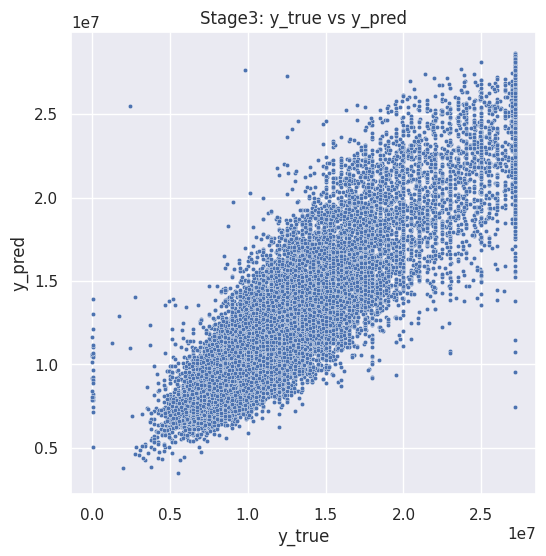

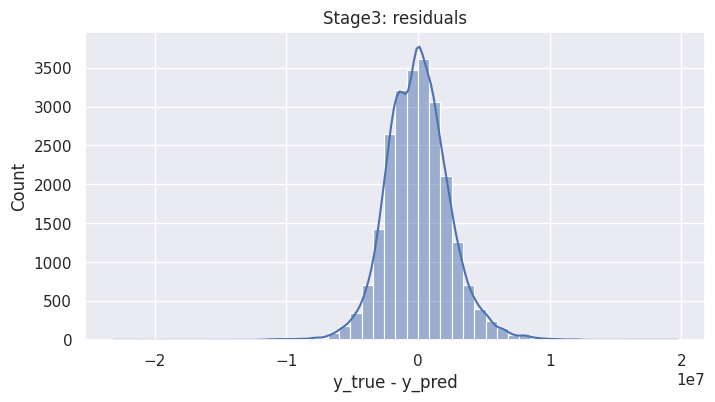

In [62]:
p_scatter = plots_dir / "stage3_true_vs_pred.png"
p_resid = plots_dir / "stage3_residuals.png"

plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.asarray(y_test), y=np.asarray(pred), s=10)
plt.title("Stage3: y_true vs y_pred")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.savefig(p_scatter, dpi=150, bbox_inches="tight")
# plt.close()

resid = np.asarray(y_test) - np.asarray(pred)
plt.figure(figsize=(8, 4))
sns.histplot(resid, bins=50, kde=True)
plt.title("Stage3: residuals")
plt.xlabel("y_true - y_pred")
plt.savefig(p_resid, dpi=150, bbox_inches="tight")
# plt.close()

str(p_scatter), str(p_resid)


### Логирование артефактов в MLflow

In [63]:
import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

# на всякий случай
setup_mlflow()

run_name = "03_feature_generation"

summary_md = (
    "## Этап 3. Итог\n\n"
    f"- manual_features_added_cnt: {len(manual_added_cols)}\n"
    f"- manual_feature_names: {manual_added_cols}\n"
    f"- autofeat_added_cnt: {autofeat_added_cnt}\n"
    f"- n_features_final: {X_train_fe_final.shape[1]}\n"
    f"- RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}\n"
    f"- fit_time_sec={times['fit_time_sec']:.4f}, predict_time_sec={times['predict_time_sec']:.4f}\n"
)

stage3_dir = ART_DIR / "stage3"
stage3_dir.mkdir(exist_ok=True)
summary_path = stage3_dir / "stage3_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tag("stage", "Stage3_FE")

    mlflow.log_param("table_name", TABLE_NAME)
    mlflow.log_param("target_col", TARGET_COL)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.log_param("manual_features_added_cnt", int(len(manual_added_cols)))
    mlflow.log_param("manual_feature_names", ",".join(manual_added_cols))

    mlflow.log_param("autofeat_added_cnt", int(autofeat_added_cnt))
    mlflow.log_param("autofeat_params", str(autofeat_params))

    mlflow.log_metrics(metrics)
    mlflow.log_metrics(times)

    if p_scatter.exists():
        mlflow.log_artifact(str(p_scatter), artifact_path="plots")
    if p_resid.exists():
        mlflow.log_artifact(str(p_resid), artifact_path="plots")

    mlflow.log_artifact(str(summary_path), artifact_path="reports")

    log_environment()
    if NOTEBOOK_PATH.exists():
        mlflow.log_artifact(str(NOTEBOOK_PATH), artifact_path="notebook")

    signature = infer_signature(X_test_fe_final.head(50), model.predict(X_test_fe_final.head(50)))
    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="model",
        signature=signature,
        input_example=X_test_fe_final.head(5),
        registered_model_name=REGISTERED_MODEL_NAME,
    )

client = MlflowClient()
versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
latest_version = max([int(v.version) for v in versions]) if versions else None

print("Registered model:", REGISTERED_MODEL_NAME)
print("Latest version:", latest_version)
print("Run id:", run.info.run_id)
print("Model URI:", model_info.model_uri)


2025-12-26 07:09:09,278 INFO: Found credentials in environment variables.
Registered model 'real_estate_price_model_matevosov' already exists. Creating a new version of this model...
2025/12/26 07:09:15 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: real_estate_price_model_matevosov, version 3


Registered model: real_estate_price_model_matevosov
Latest version: 3
Run id: 5b3c89ae4069465c9166ea3a27a61441
Model URI: runs:/5b3c89ae4069465c9166ea3a27a61441/model


Created version '3' of model 'real_estate_price_model_matevosov'.


## Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [ ]:
# 4.1 Отбор признаков при помощи метода номер 1

In [ ]:
# 4.2 Отбор признаков при помощи метода номер 2

In [ ]:
# 4.3 Анализ отобранных признаков при помощи двух методов и формирование финального списка с признаками для модели

In [ ]:
# 4.4 Обучение новой версии модели

In [ ]:
# 4.5 Логирование всех артефактов в MLflow

## Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [ ]:
# 5.1 Подбор гиперпарметров при мощи метода номер 1

In [ ]:
# 5.2 Подбор гиперпарметров при мощи метода номер 2

In [ ]:
# 5.3 Формирование списка гиперпараметров для новой модели

In [ ]:
# 5.4 Обуение финальной версии модели

In [ ]:
# 5.5 Логирование артефактов в MLflow